# Обзо данных

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("../venv_course/train.csv",encoding="cp1251")
df.head(5)

,Column1,index,assessment,tags,text,trend_id_res0,trend_id_res1,trend_id_res2,trend_id_res3,trend_id_res4,...,trend_id_res40,trend_id_res41,trend_id_res42,trend_id_res43,trend_id_res44,trend_id_res45,trend_id_res46,trend_id_res47,trend_id_res48,trend_id_res49
0,0.0,5652.0,6.0,"{ASSORTMENT,PROMOTIONS,DELIVERY}","Маленький выбор товаров, хотелось бы ассортиме...",0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,18092.0,4.0,"{ASSORTMENT,PRICE,PRODUCTS_QUALITY,DELIVERY}",Быстро,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,13845.0,6.0,"{DELIVERY,PROMOTIONS,PRICE,ASSORTMENT,SUPPORT}",Доставка постоянно задерживается,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.0,25060.0,6.0,"{PRICE,PROMOTIONS,ASSORTMENT}",Наценка и ассортимент расстраивают,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,1428.0,6.0,"{PRICE,PROMOTIONS}",Можно немного скинуть минимальную сумму заказа...,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df.shape

(4626, 55)

In [4]:
df.columns

Index(['Column1', 'index', 'assessment', 'tags', 'text', 'trend_id_res0',
       'trend_id_res1', 'trend_id_res2', 'trend_id_res3', 'trend_id_res4',
       'trend_id_res5', 'trend_id_res6', 'trend_id_res7', 'trend_id_res8',
       'trend_id_res9', 'trend_id_res10', 'trend_id_res11', 'trend_id_res12',
       'trend_id_res13', 'trend_id_res14', 'trend_id_res15', 'trend_id_res16',
       'trend_id_res17', 'trend_id_res18', 'trend_id_res19', 'trend_id_res20',
       'trend_id_res21', 'trend_id_res22', 'trend_id_res23', 'trend_id_res24',
       'trend_id_res25', 'trend_id_res26', 'trend_id_res27', 'trend_id_res28',
       'trend_id_res29', 'trend_id_res30', 'trend_id_res31', 'trend_id_res32',
       'trend_id_res33', 'trend_id_res34', 'trend_id_res35', 'trend_id_res36',
       'trend_id_res37', 'trend_id_res38', 'trend_id_res39', 'trend_id_res40',
       'trend_id_res41', 'trend_id_res42', 'trend_id_res43', 'trend_id_res44',
       'trend_id_res45', 'trend_id_res46', 'trend_id_res47', 'tren

# Целевой переменной станет tags
нужно посомтреть уникальные значения и понять задачу классификации

In [5]:
df[df["tags"].isna()]["text"][2047]

'Разредился телефон даже не попытались попасть подъезд'

In [6]:
df[df["tags"].isna()]["text"]

57                                                  говно
478     Быстрая и деш?вая доставка продуктов за минут ...
553                    Уберите принудительное обновление.
1650    Долго доставляют заказы, бывают моменты когда ...
2047    Разредился телефон даже не попытались попасть ...
2124                                                   Ты
2577                             Идиоты, клоуны??????????
2661                           Думаю хорошо, все нравится
3260    В последнее время увеличилось время доставки. ...
3399                                          Все отлично
4172                       бонусы спасибо не дали списать
Name: text, dtype: str

In [7]:
tags=df["tags"].dropna()

In [8]:
def split_tags(string):
    string=string[1:len(string)-1].split(",")
    return string

In [9]:
tags=tags.apply(split_tags)

In [10]:
tags[0]

['ASSORTMENT', 'PROMOTIONS', 'DELIVERY']

In [11]:
tags_all = [item for tag in tags for item in tag]

In [12]:
from collections import Counter
categories=Counter(tags_all)
categories

Counter({'DELIVERY': 3055,
         'ASSORTMENT': 2121,
         'PRICE': 2073,
         'PROMOTIONS': 1743,
         'PRODUCTS_QUALITY': 1459,
         'SUPPORT': 1222,
         'CATALOG_NAVIGATION': 587,
         'PAYMENT': 429,
         '': 2,
         'применяется бОльшая))))': 1})

In [13]:
categories.values()

dict_values([2121, 1743, 3055, 2073, 1459, 1222, 587, 429, 2, 1])

<BarContainer object of 10 artists>

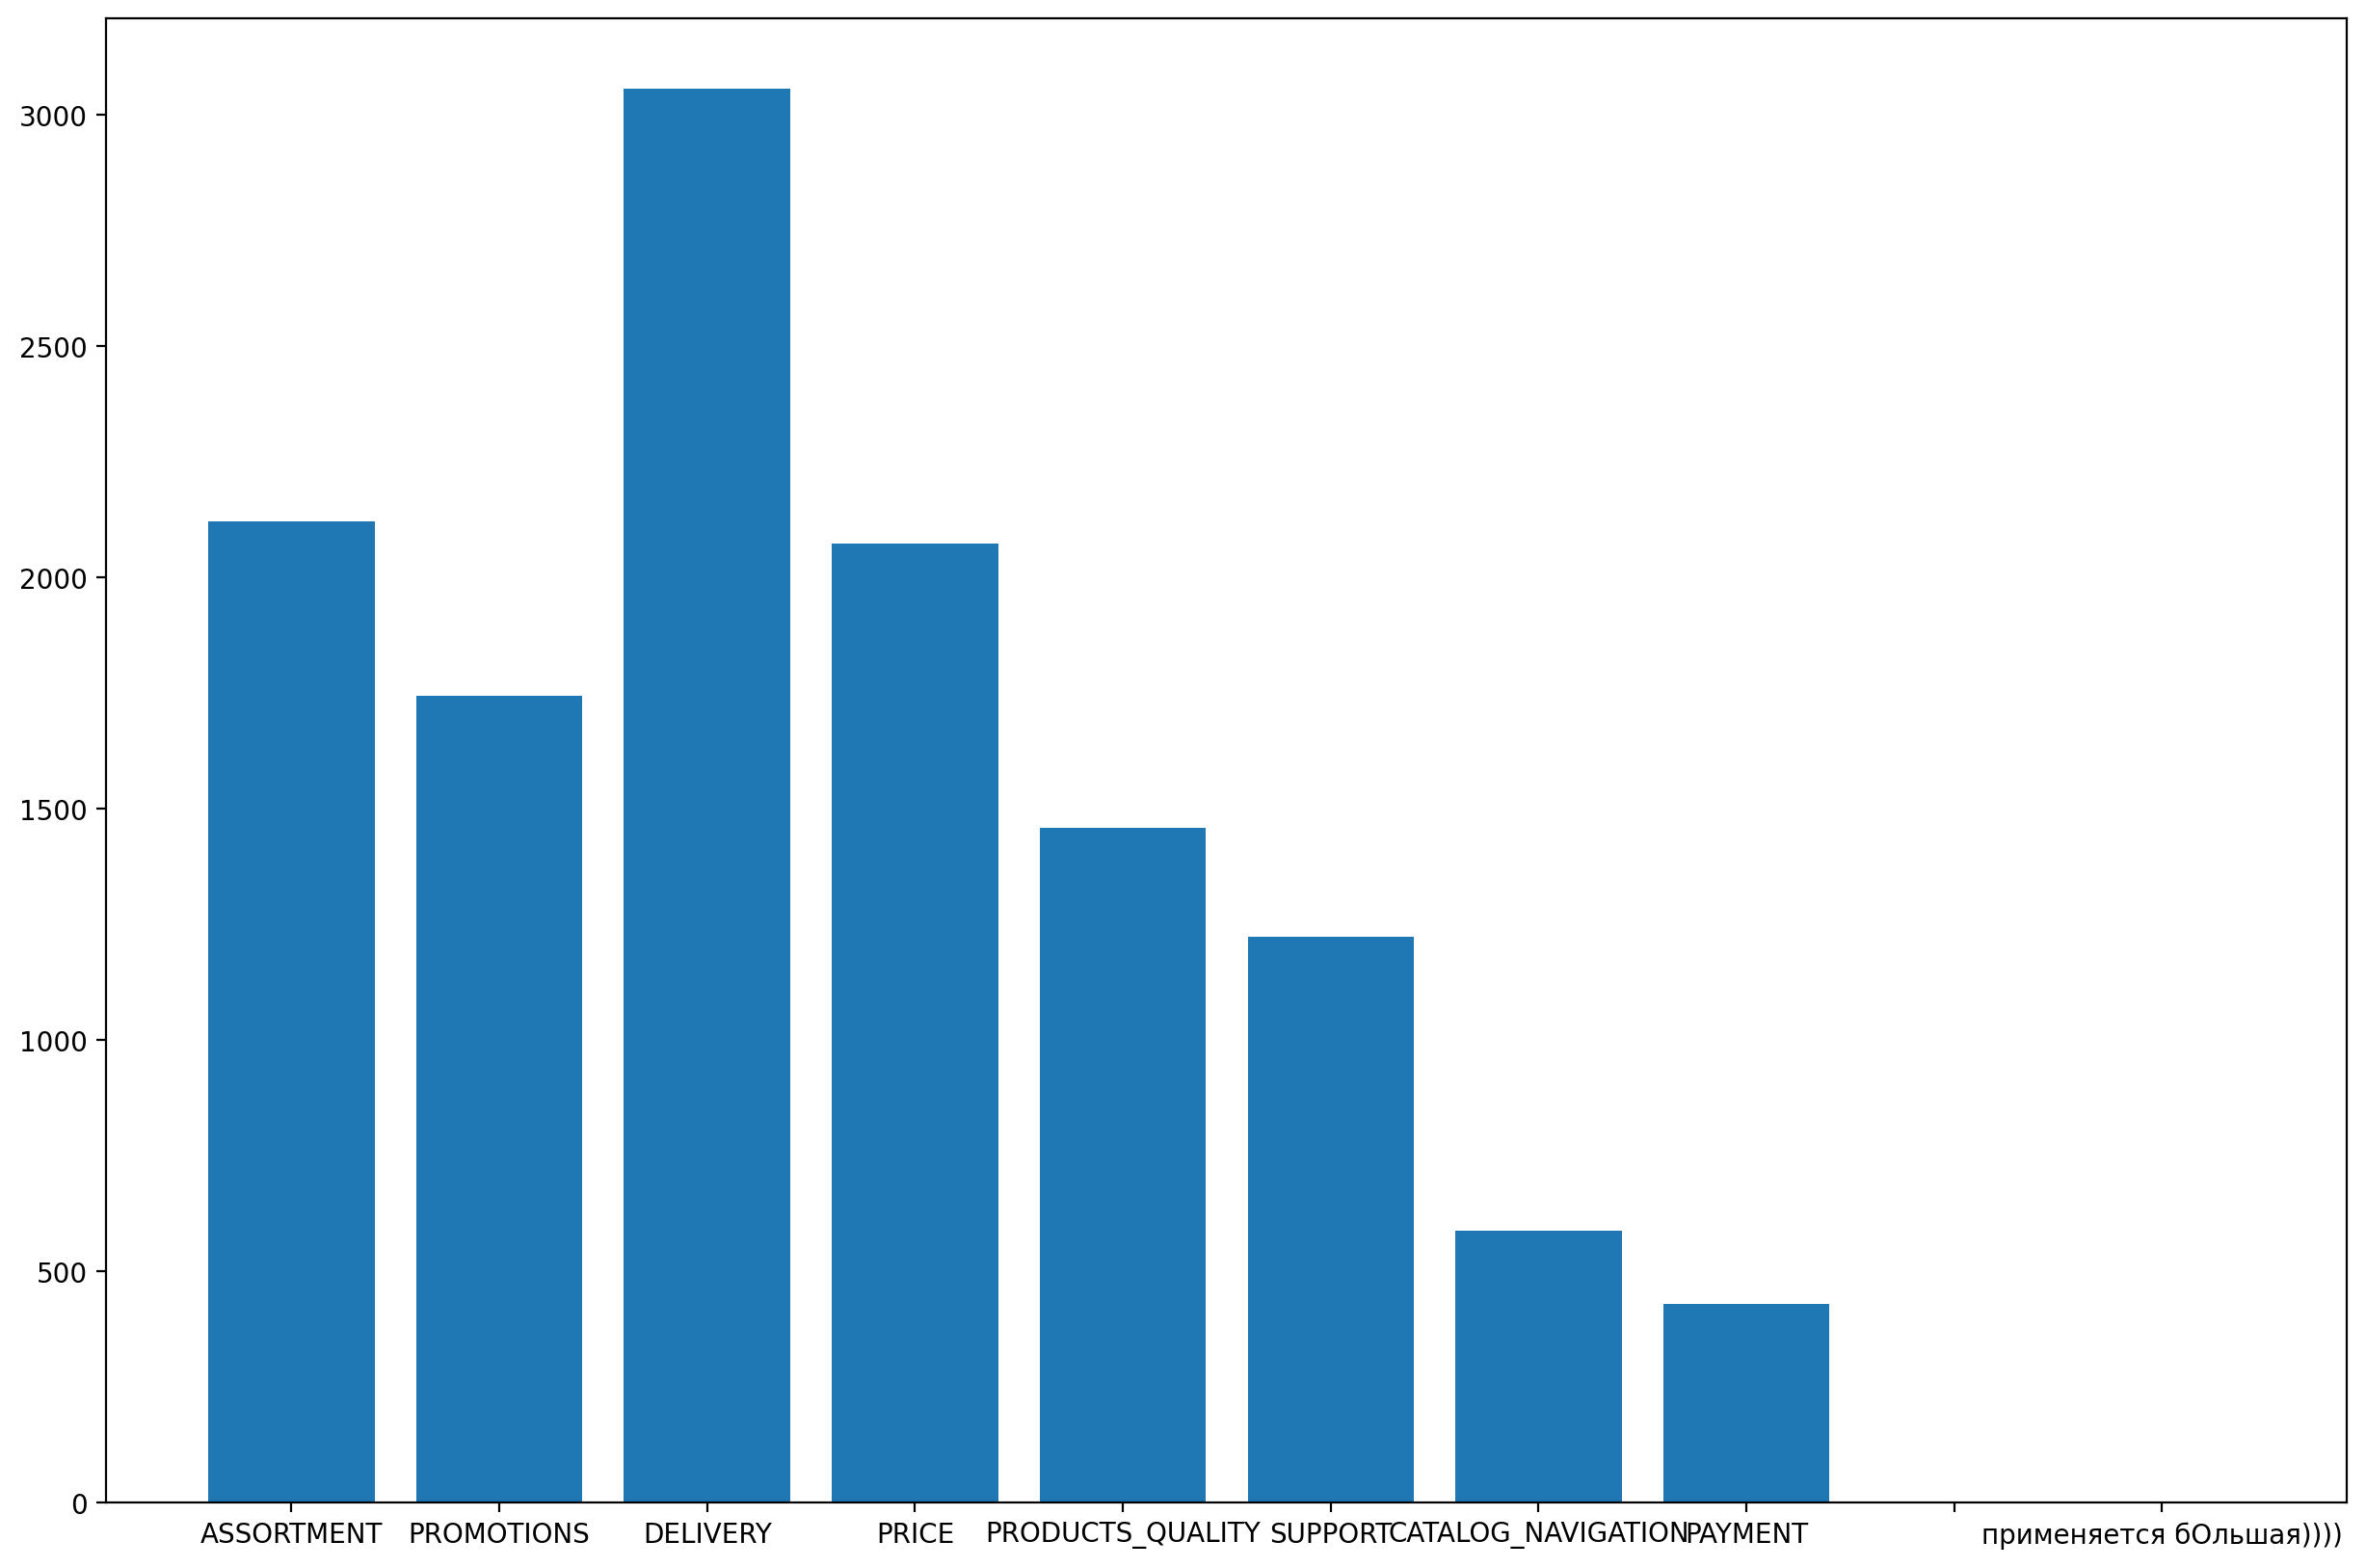

In [14]:
from matplotlib import pyplot as plt
plt.figure(figsize=(15,10))
plt.bar(categories.keys(),categories.values())

в топ проблем входят проблемы с доставкой, асортиментом и ценой

можно выделить 8 основных категорий 

Оригинал	Перевод

DELIVERY	ДОСТАВКА

ASSORTMENT	АССОРТИМЕНТ (или ВЫБОР ТОВАРОВ)

PRICE	ЦЕНА

PROMOTIONS	АКЦИИ (или СПЕЦПРЕДЛОЖЕНИЯ)

PRODUCTS_QUALITY	КАЧЕСТВО ТОВАРОВ

SUPPORT	ПОДДЕРЖКА (или СЛУЖБА ПОДДЕРЖКИ)

CATALOG_NAVIGATION	НАВИГАЦИЯ ПО КАТАЛОГУ

PAYMENT	ОПЛАТА

# One hot кодирование, задача переходит в мультиклассовую классификацию для создания векторов категорий проблемы

In [15]:
df.shape

(4626, 55)

In [16]:
df.dropna(inplace=True)


In [17]:
df.shape

(4609, 55)

In [18]:
categories=list(categories.keys())
categories=categories[:len(categories)-2]
categories

['ASSORTMENT',
 'PROMOTIONS',
 'DELIVERY',
 'PRICE',
 'PRODUCTS_QUALITY',
 'SUPPORT',
 'CATALOG_NAVIGATION',
 'PAYMENT']

In [19]:
train_df=pd.DataFrame(data={"text":df["text"],"tags":df["tags"]},columns=["text","tags",*categories])
train_df

,text,tags,ASSORTMENT,PROMOTIONS,DELIVERY,PRICE,PRODUCTS_QUALITY,SUPPORT,CATALOG_NAVIGATION,PAYMENT
0,"Маленький выбор товаров, хотелось бы ассортиме...","{ASSORTMENT,PROMOTIONS,DELIVERY}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Быстро,"{ASSORTMENT,PRICE,PRODUCTS_QUALITY,DELIVERY}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Доставка постоянно задерживается,"{DELIVERY,PROMOTIONS,PRICE,ASSORTMENT,SUPPORT}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Наценка и ассортимент расстраивают,"{PRICE,PROMOTIONS,ASSORTMENT}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Можно немного скинуть минимальную сумму заказа...,"{PRICE,PROMOTIONS}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4621,Привезли прокисший суп,{PRODUCTS_QUALITY},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4622,пойдет,{DELIVERY},NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4623,Не дают абузить поддержка не возвращает деньги...,"{PROMOTIONS,PRICE,SUPPORT,PRODUCTS_QUALITY}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4624,"Очень плохая доставка в первую очередь, постоя...","{DELIVERY,PRODUCTS_QUALITY}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
train_df.fillna(0,inplace=True)

,text,tags,ASSORTMENT,PROMOTIONS,DELIVERY,PRICE,PRODUCTS_QUALITY,SUPPORT,CATALOG_NAVIGATION,PAYMENT
0,"Маленький выбор товаров, хотелось бы ассортиме...","{ASSORTMENT,PROMOTIONS,DELIVERY}",0,0,0,0,0,0,0,0
1,Быстро,"{ASSORTMENT,PRICE,PRODUCTS_QUALITY,DELIVERY}",0,0,0,0,0,0,0,0
2,Доставка постоянно задерживается,"{DELIVERY,PROMOTIONS,PRICE,ASSORTMENT,SUPPORT}",0,0,0,0,0,0,0,0
3,Наценка и ассортимент расстраивают,"{PRICE,PROMOTIONS,ASSORTMENT}",0,0,0,0,0,0,0,0
4,Можно немного скинуть минимальную сумму заказа...,"{PRICE,PROMOTIONS}",0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...
4621,Привезли прокисший суп,{PRODUCTS_QUALITY},0,0,0,0,0,0,0,0
4622,пойдет,{DELIVERY},0,0,0,0,0,0,0,0
4623,Не дают абузить поддержка не возвращает деньги...,"{PROMOTIONS,PRICE,SUPPORT,PRODUCTS_QUALITY}",0,0,0,0,0,0,0,0
4624,"Очень плохая доставка в первую очередь, постоя...","{DELIVERY,PRODUCTS_QUALITY}",0,0,0,0,0,0,0,0


In [21]:
type(categories[0])

str

In [22]:
for tag in categories:
    train_df[tag]=train_df["tags"].apply(lambda x: 1 if tag in x else 0)

In [23]:
train_df=train_df.drop(columns=["tags"])
train_df

,text,ASSORTMENT,PROMOTIONS,DELIVERY,PRICE,PRODUCTS_QUALITY,SUPPORT,CATALOG_NAVIGATION,PAYMENT
0,"Маленький выбор товаров, хотелось бы ассортиме...",1,1,1,0,0,0,0,0
1,Быстро,1,0,1,1,1,0,0,0
2,Доставка постоянно задерживается,1,1,1,1,0,1,0,0
3,Наценка и ассортимент расстраивают,1,1,0,1,0,0,0,0
4,Можно немного скинуть минимальную сумму заказа...,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...
4621,Привезли прокисший суп,0,0,0,0,1,0,0,0
4622,пойдет,0,0,1,0,0,0,0,0
4623,Не дают абузить поддержка не возвращает деньги...,0,1,0,1,1,1,0,0
4624,"Очень плохая доставка в первую очередь, постоя...",0,0,1,0,1,0,0,0


# Получили датафрейм с 8 целевыми переменными

In [24]:
train_df[train_df["SUPPORT"]==1]["text"]

2                        Доставка постоянно задерживается
8       Отличное приложение спасибо большое за доставк...
11      Цены на некоторые позиции взлетели не оправдан...
13      Страдает доставка, очень долго, хотя пишите [N...
14      Очень очень очень долгая доставка. [NUM] заказ...
                              ...                        
4606                                               Привет
4610    Я жду заказ [NUM]й час, при обещанных [NUM].[N...
4619                                                   ??
4620    Продукты приносят не всегда качественные, бана...
4623    Не дают абузить поддержка не возвращает деньги...
Name: text, Length: 1221, dtype: str

In [25]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device name:", torch.cuda.get_device_name(0))

PyTorch version: 2.10.0+cu128
CUDA available: True
Device name: NVIDIA GeForce RTX 3060


In [26]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizerFast, BertForSequenceClassification  # AdamW убрали
from torch.optim import AdamW  # <-- правильный источник
from sklearn.metrics import hamming_loss, jaccard_score, classification_report
import numpy as np
import pandas as pd

/home/sasha/Python/VKR/pytorch_bert/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels  # DataFrame или numpy array
        self.tokenizer = tokenizer
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {key: val.squeeze(0) for key, val in enc.items()}
        
        # ✅ Если labels — DataFrame:
        if isinstance(self.labels, pd.DataFrame):
            label_tensor = torch.tensor(self.labels.iloc[idx].values, dtype=torch.float)
        else:  # numpy array
            label_tensor = torch.tensor(self.labels[idx], dtype=torch.float)
            
        item['labels'] = label_tensor
        return item

In [28]:
texts,labels=train_df["text"],train_df.drop(columns=["text"])

In [29]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# -----------------------------
# 1. Разделяем данные и сбрасываем индексы
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# Сброс индексов, чтобы DataFrame/Series имели позиции 0..N-1
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# -----------------------------
# 2. Создаём датасеты
# -----------------------------
train_dataset = TextDataset(X_train, y_train, tokenizer)
test_dataset  = TextDataset(X_test, y_test, tokenizer)

# -----------------------------
# 3. Создаём DataLoader
# -----------------------------
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16)

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=8,
    problem_type="multi_label_classification"  # ключевой момент
)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14760.58it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider t

In [31]:
train_loader

In [43]:
epochs = 10

for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")


Epoch 1, Loss: 0.3030
Epoch 2, Loss: 0.2785
Epoch 3, Loss: 0.2588
Epoch 4, Loss: 0.2397
Epoch 5, Loss: 0.2195
Epoch 6, Loss: 0.2012
Epoch 7, Loss: 0.1871
Epoch 8, Loss: 0.1676
Epoch 9, Loss: 0.1577
Epoch 10, Loss: 0.1466


In [52]:
import torch
from transformers import BertForSequenceClassification, BertTokenizerFast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained("bert_model")
tokenizer = BertTokenizerFast.from_pretrained("bert_model")

model.to(device)        # <-- обязательно
model.eval()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 15509.88it/s]


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [53]:
model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].cpu().numpy()
        
        outputs = model(input_ids, attention_mask=attention_mask)
        probs = torch.sigmoid(outputs.logits).cpu().numpy()
        
        all_probs.append(probs)
        all_labels.append(labels)

all_probs = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

In [57]:
thresholds = [0.2]*8
y_pred = (all_probs >= thresholds).astype(int)

# -----------------------------
# 7. Метрики
# -----------------------------
print("Hamming Loss:", hamming_loss(all_labels, y_pred))
print("Jaccard Score:", jaccard_score(all_labels, y_pred, average="samples"))
print(classification_report(all_labels, y_pred, target_names=categories))

Hamming Loss: 0.34747830802603036
Jaccard Score: 0.46624057432083466
                    precision    recall  f1-score   support

        ASSORTMENT       0.52      0.84      0.64       434
        PROMOTIONS       0.49      0.70      0.58       354
          DELIVERY       0.75      0.93      0.83       606
             PRICE       0.52      0.71      0.60       413
  PRODUCTS_QUALITY       0.39      0.73      0.51       252
           SUPPORT       0.32      0.73      0.45       220
CATALOG_NAVIGATION       0.20      0.44      0.27       108
           PAYMENT       0.22      0.33      0.27        95

         micro avg       0.49      0.76      0.60      2482
         macro avg       0.43      0.67      0.52      2482
      weighted avg       0.52      0.76      0.61      2482
       samples avg       0.56      0.81      0.60      2482



In [40]:
model.save_pretrained("bert_model")
tokenizer.save_pretrained("bert_model")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.72it/s]


('bert_model/tokenizer_config.json', 'bert_model/tokenizer.json')